# PTSD Simulation Database - Comprehensive EDA & Analysis
## Exploratory Data Analysis of the Complete Database

This notebook provides comprehensive analysis of the PTSD Simulation Database including:
- **Database Overview**: Structure, tables, and relationships
- **Univariate Analysis**: Individual column distributions and statistics
- **Bivariate Analysis**: Relationships between variables
- **Person-Specific Profiles**: Detailed analysis of individual participants
- **Therapist Performance Metrics**: Analysis by therapist
- **Scenario & Reaction Analysis**: Patterns and correlations
- **Assessment Scores Distribution**: Trauma sensitivity, emotional regulation, etc.
- **Statistical Summaries & Reports**: Key metrics and insights

**Created**: February 2026 | **Database**: PTSD Simulation DB | **Purpose**: External Presentation & Internal Analysis

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 1. Database Connection & Configuration

In [3]:
# Database Configuration
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# MySQL Configuration
MYSQL_USER = os.getenv("MYSQL_USER", "root")
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD", "")
MYSQL_HOST = os.getenv("MYSQL_HOST", "localhost")
MYSQL_PORT = os.getenv("MYSQL_PORT", "3306")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE", "ptsd_simulation_db")

# Create database connection
SQLALCHEMY_DATABASE_URL = f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
engine = create_engine(SQLALCHEMY_DATABASE_URL, echo=False)

# Test connection
try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT 1"))
        print("✓ Database connection successful!")
        print(f"✓ Database: {MYSQL_DATABASE}")
except Exception as e:
    print(f"✗ Connection failed: {e}")

✓ Database connection successful!
✓ Database: ptsd_simulation_db_new


## 2. Load All Database Tables

In [4]:
# Load all tables from database
print("Loading database tables...\n")

# Core Tables
persons = pd.read_sql("SELECT * FROM persons", engine)
therapists = pd.read_sql("SELECT * FROM therapists", engine)
scenarios = pd.read_sql("SELECT * FROM scenarios", engine)
reactions = pd.read_sql("SELECT * FROM reactions", engine)
reports = pd.read_sql("SELECT * FROM reports", engine)

# Junction/Relationship Tables
participates = pd.read_sql("SELECT * FROM participates", engine)
assigns = pd.read_sql("SELECT * FROM assigns", engine)
exhibits = pd.read_sql("SELECT * FROM exhibits", engine)
triggers = pd.read_sql("SELECT * FROM triggers", engine)

# Authentication & Assessment Tables
users = pd.read_sql("SELECT * FROM users", engine)
questionnaires = pd.read_sql("SELECT * FROM questionnaires", engine)
assessments = pd.read_sql("SELECT * FROM assessments", engine)
responses = pd.read_sql("SELECT * FROM responses", engine)

# Display data summary
print("="*70)
print("DATABASE TABLES LOADED SUCCESSFULLY")
print("="*70)
print(f"✓ Persons:        {len(persons)} records")
print(f"✓ Therapists:     {len(therapists)} records")
print(f"✓ Scenarios:      {len(scenarios)} records")
print(f"✓ Reactions:      {len(reactions)} records")
print(f"✓ Reports:        {len(reports)} records")
print(f"✓ Assessments:    {len(assessments)} records")
print(f"✓ Questionnaires: {len(questionnaires)} records")
print(f"✓ Responses:      {len(responses)} records")
print(f"✓ Users:          {len(users)} records")
print(f"✓ Participates:   {len(participates)} records (Person-Scenario)")
print(f"✓ Assigns:        {len(assigns)} records (Therapist-Scenario)")
print(f"✓ Exhibits:       {len(exhibits)} records (Person-Reaction)")
print(f"✓ Triggers:       {len(triggers)} records (Scenario-Reaction)")
print("="*70)

Loading database tables...

DATABASE TABLES LOADED SUCCESSFULLY
✓ Persons:        30 records
✓ Therapists:     8 records
✓ Scenarios:      12 records
✓ Reactions:      92 records
✓ Reports:        92 records
✓ Assessments:    57 records
✓ Questionnaires: 20 records
✓ Responses:      1140 records
✓ Users:          38 records
✓ Participates:   80 records (Person-Scenario)
✓ Assigns:        0 records (Therapist-Scenario)
✓ Exhibits:       92 records (Person-Reaction)
✓ Triggers:       92 records (Scenario-Reaction)


## 3. Database Schema Overview & Data Types

In [4]:
# Function to display table info
def display_table_info(df, table_name):
    print(f"\n{'='*70}")
    print(f"TABLE: {table_name.upper()}")
    print(f"{'='*70}")
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nColumns & Data Types:")
    print(df.dtypes)
    print(f"\nMissing Values:")
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(missing[missing > 0])
    else:
        print("✓ No missing values")
    print(f"\nFirst few records:")
    print(df.head(3))

# Display info for main tables
display_table_info(persons, "Persons")
display_table_info(therapists, "Therapists")
display_table_info(scenarios, "Scenarios")
display_table_info(reactions, "Reactions")
display_table_info(reports, "Reports")


TABLE: PERSONS
Shape: 30 rows × 9 columns

Columns & Data Types:
id                        int64
name                        str
rank                        str
age                       int64
gender                      str
service_years             int64
therapist_id              int64
user_id                  object
current_assessment_id    object
dtype: object

Missing Values:
user_id                  30
current_assessment_id    30
dtype: int64

First few records:
   id             name     rank  age  gender  service_years  therapist_id  \
0   1      Alex Garcia    Major   35  Female              4             7   
1   2  Emily Hernandez  Private   23  Female              2             4   
2   3     Daniel Smith  Private   22    Male              2             1   

  user_id current_assessment_id  
0    None                  None  
1    None                  None  
2    None                  None  

TABLE: THERAPISTS
Shape: 8 rows × 5 columns

Columns & Data Types:
id           

## 4. Persons Analysis - Demographics & Characteristics

PERSONS DEMOGRAPHICS ANALYSIS

Total Persons: 30
Age Statistics:
count    30.000000
mean     33.766667
std       6.785803
min      22.000000
25%      28.500000
50%      34.500000
75%      39.750000
max      45.000000
Name: age, dtype: float64

Service Years Statistics:
count    30.000000
mean      8.266667
std       5.212276
min       1.000000
25%       4.000000
50%       8.500000
75%      11.750000
max      18.000000
Name: service_years, dtype: float64

Gender Distribution:
gender
Female    15
Male      15
Name: count, dtype: int64

Rank Distribution:
rank
Major             9
Private           5
Captain           5
Staff Sergeant    4
Lieutenant        3
Corporal          2
Sergeant          2
Name: count, dtype: int64

Therapist Assignment:
  - With Therapist: 30
  - Without Therapist: 0


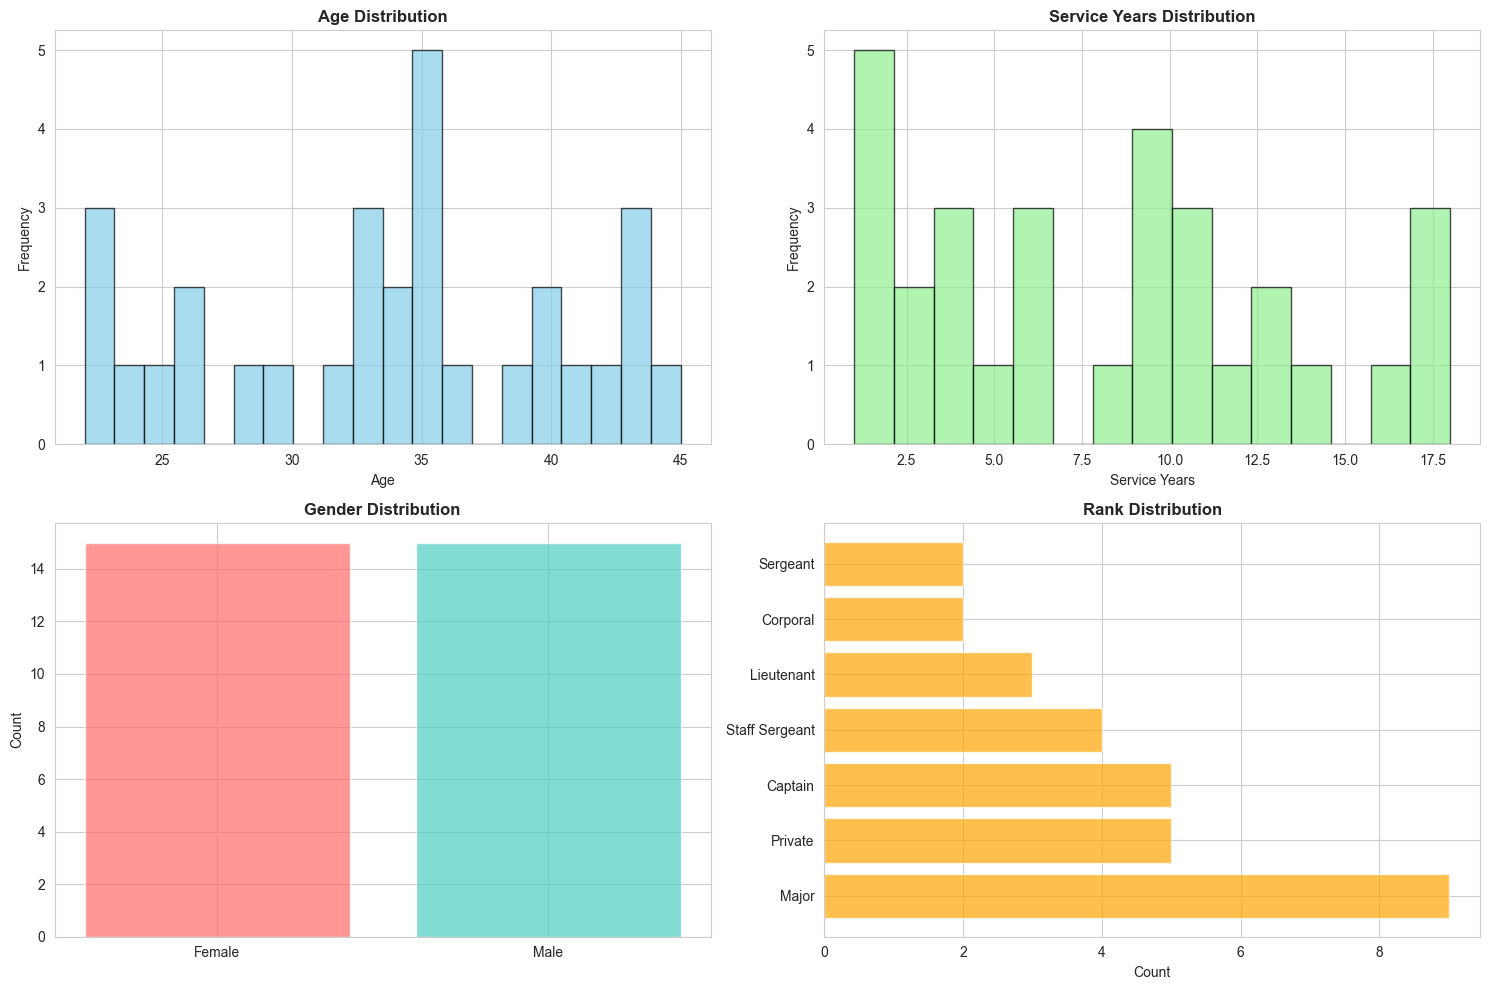

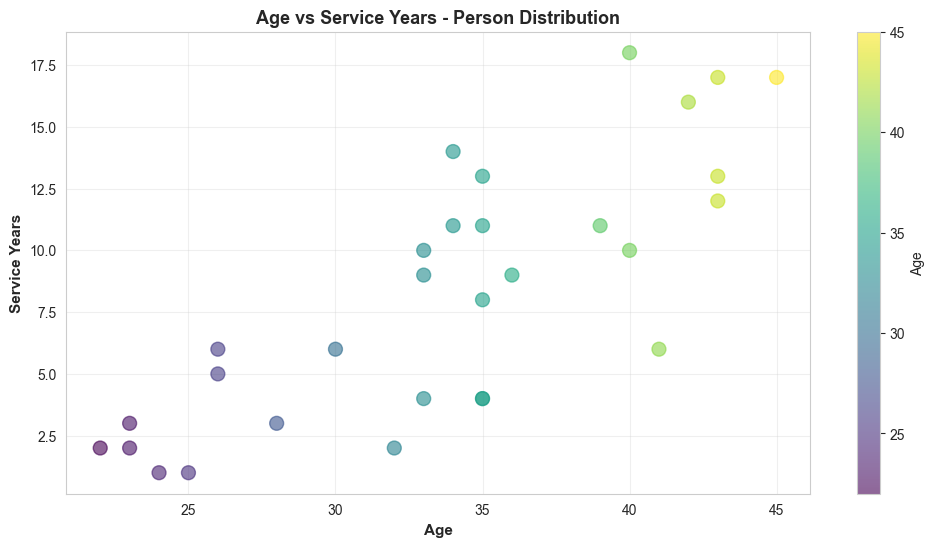


✓ Demographics analysis complete!


In [5]:
# Demographics Overview
print("="*70)
print("PERSONS DEMOGRAPHICS ANALYSIS")
print("="*70)
print(f"\nTotal Persons: {len(persons)}")
print(f"Age Statistics:")
print(persons['age'].describe())
print(f"\nService Years Statistics:")
print(persons['service_years'].describe())
print(f"\nGender Distribution:")
print(persons['gender'].value_counts())
print(f"\nRank Distribution:")
print(persons['rank'].value_counts())
print(f"\nTherapist Assignment:")
print(f"  - With Therapist: {persons['therapist_id'].notna().sum()}")
print(f"  - Without Therapist: {persons['therapist_id'].isna().sum()}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age Distribution
axes[0, 0].hist(persons['age'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Service Years Distribution
axes[0, 1].hist(persons['service_years'], bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Service Years Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Service Years')
axes[0, 1].set_ylabel('Frequency')

# Gender Distribution
gender_counts = persons['gender'].value_counts()
axes[1, 0].bar(gender_counts.index, gender_counts.values, color=['#FF6B6B', '#4ECDC4'], alpha=0.7)
axes[1, 0].set_title('Gender Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count')

# Rank Distribution
rank_counts = persons['rank'].value_counts()
axes[1, 1].barh(rank_counts.index, rank_counts.values, color='orange', alpha=0.7)
axes[1, 1].set_title('Rank Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.show()

# Age vs Service Years
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(persons['age'], persons['service_years'], 
                     c=persons['age'], cmap='viridis', s=100, alpha=0.6)
ax.set_xlabel('Age', fontsize=11, fontweight='bold')
ax.set_ylabel('Service Years', fontsize=11, fontweight='bold')
ax.set_title('Age vs Service Years - Person Distribution', fontsize=13, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Age')
plt.grid(True, alpha=0.3)
plt.show()

print("\n✓ Demographics analysis complete!")

## 5. Assessment Scores Analysis - Psychological Profiles

ASSESSMENT SCORES ANALYSIS

Total Assessments: 57

Trauma Sensitivity Statistics:
count    57.000000
mean      0.595725
std       0.193618
min       0.136159
25%       0.439214
50%       0.632094
75%       0.749201
max       0.896712
Name: trauma_sensitivity, dtype: float64

Emotional Regulation Statistics:
count    57.000000
mean      0.560017
std       0.221461
min       0.175304
25%       0.382276
50%       0.577831
75%       0.755407
max       0.902013
Name: emotional_regulation, dtype: float64

Recovery Rate Statistics:
count    57.000000
mean      0.551958
std       0.215911
min       0.143940
25%       0.361943
50%       0.543042
75%       0.730066
max       0.925128
Name: recovery_rate, dtype: float64

Impulsivity Statistics:
count    57.000000
mean      0.593478
std       0.197268
min       0.228859
25%       0.393445
50%       0.663928
75%       0.751123
max       0.919207
Name: impulsivity, dtype: float64

Coping Mechanisms Distribution:
coping_mechanism
avoidance      19
fr

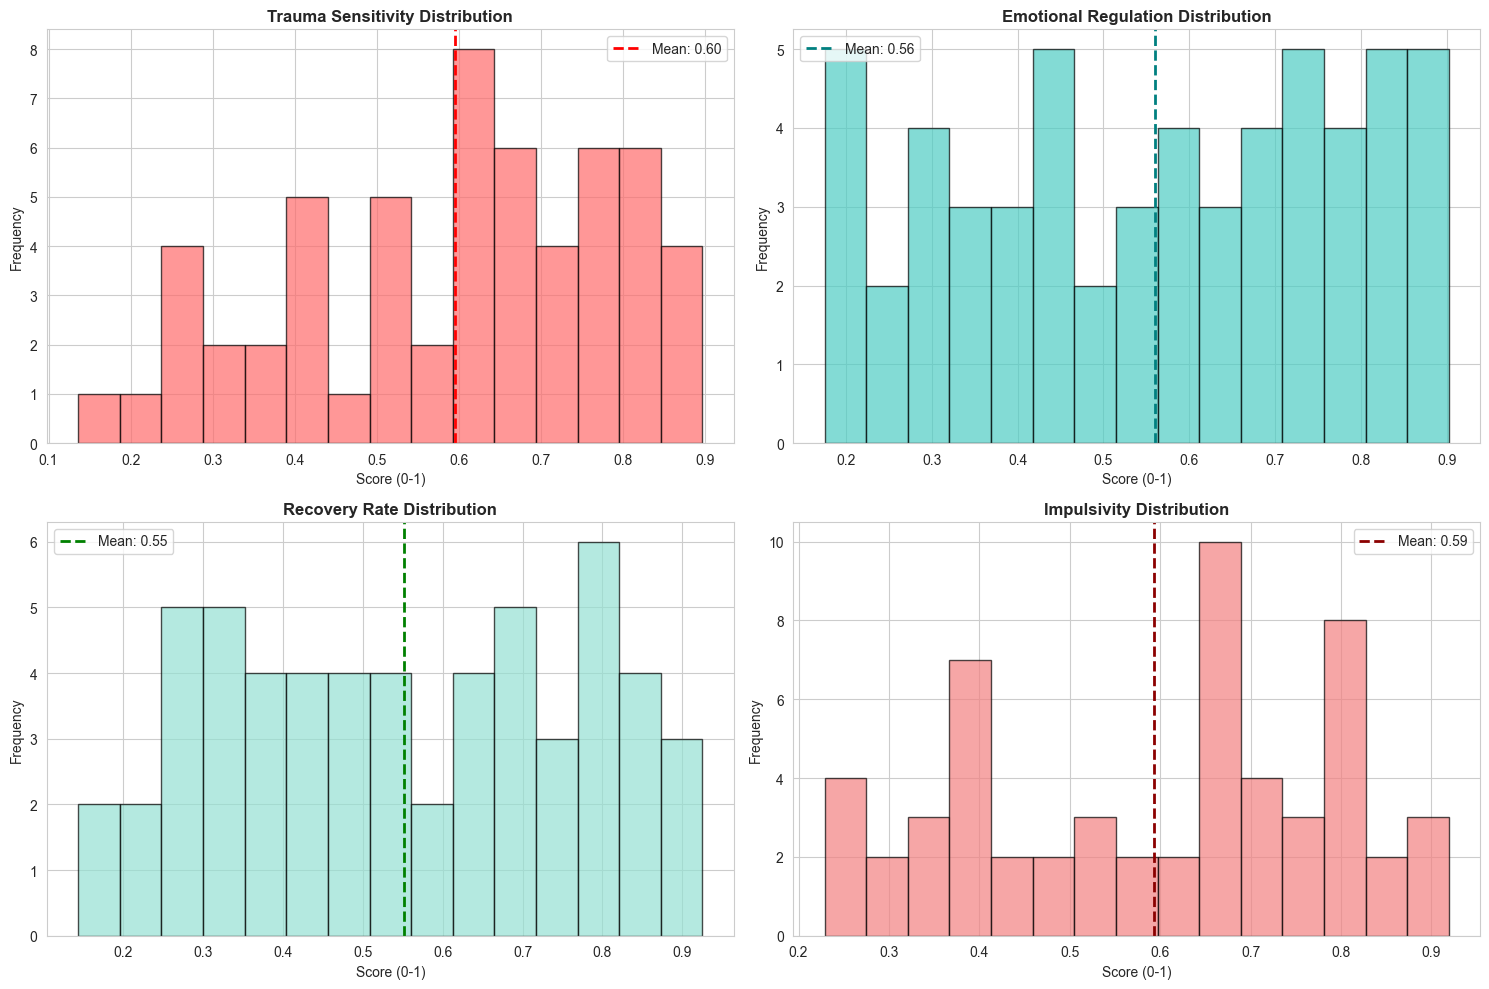

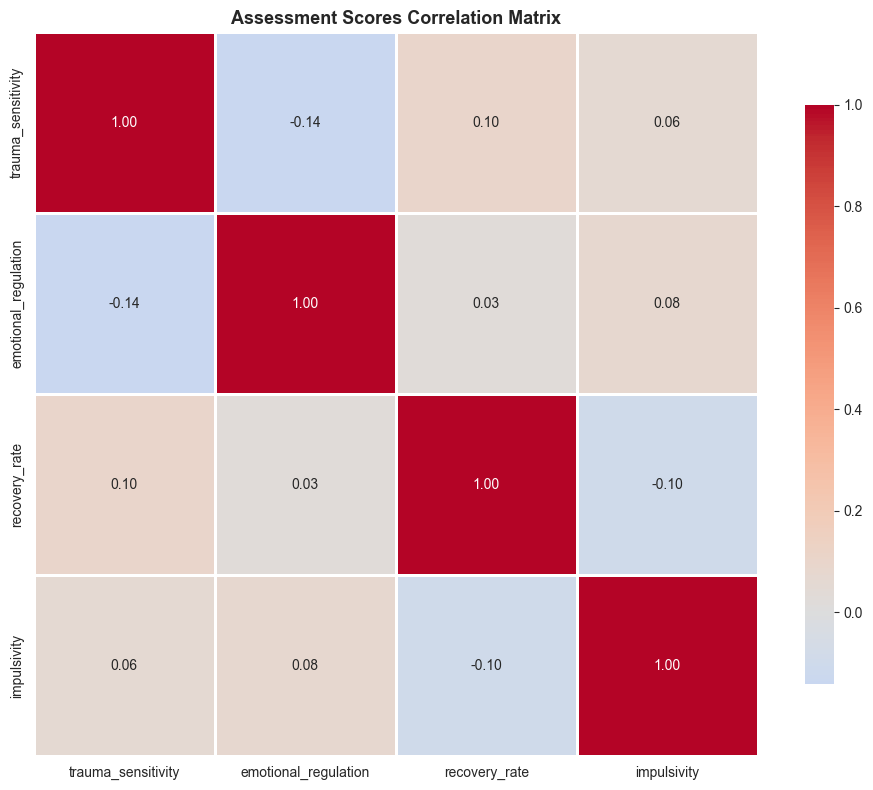


✓ Assessment analysis complete!


In [6]:
# Assessment Scores Distribution
print("="*70)
print("ASSESSMENT SCORES ANALYSIS")
print("="*70)
print(f"\nTotal Assessments: {len(assessments)}")
print(f"\nTrauma Sensitivity Statistics:")
print(assessments['trauma_sensitivity'].describe())
print(f"\nEmotional Regulation Statistics:")
print(assessments['emotional_regulation'].describe())
print(f"\nRecovery Rate Statistics:")
print(assessments['recovery_rate'].describe())
print(f"\nImpulsivity Statistics:")
print(assessments['impulsivity'].describe())

print(f"\nCoping Mechanisms Distribution:")
print(assessments['coping_mechanism'].value_counts())

# Merge assessments with persons for detailed analysis
assessments_persons = assessments.merge(persons, left_on='person_id', right_on='id', suffixes=('_assess', '_person'))

# Visualize Score Distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Trauma Sensitivity
axes[0, 0].hist(assessments['trauma_sensitivity'], bins=15, color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Trauma Sensitivity Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Score (0-1)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(assessments['trauma_sensitivity'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {assessments['trauma_sensitivity'].mean():.2f}")
axes[0, 0].legend()

# Emotional Regulation
axes[0, 1].hist(assessments['emotional_regulation'], bins=15, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Emotional Regulation Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Score (0-1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(assessments['emotional_regulation'].mean(), color='teal', linestyle='--', linewidth=2, label=f"Mean: {assessments['emotional_regulation'].mean():.2f}")
axes[0, 1].legend()

# Recovery Rate
axes[1, 0].hist(assessments['recovery_rate'], bins=15, color='#95E1D3', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Recovery Rate Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Score (0-1)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(assessments['recovery_rate'].mean(), color='green', linestyle='--', linewidth=2, label=f"Mean: {assessments['recovery_rate'].mean():.2f}")
axes[1, 0].legend()

# Impulsivity
axes[1, 1].hist(assessments['impulsivity'], bins=15, color='#F38181', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Impulsivity Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Score (0-1)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(assessments['impulsivity'].mean(), color='darkred', linestyle='--', linewidth=2, label=f"Mean: {assessments['impulsivity'].mean():.2f}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Correlation heatmap for assessment scores
score_cols = ['trauma_sensitivity', 'emotional_regulation', 'recovery_rate', 'impulsivity']
corr_matrix = assessments[score_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Assessment Scores Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Assessment analysis complete!")

## 6. Reports Analysis - PTSD Symptom Assessment

PTSD REPORTS ANALYSIS

Total Reports: 92

AVOIDANCE Distribution:
avoidance
High        56
Severe      27
Low          6
Moderate     3
Name: count, dtype: int64

RE_EXPERIENCING Distribution:
re_experiencing
Yes    83
No      9
Name: count, dtype: int64

NEGATIVE_ALTERATIONS Distribution:
negative_alterations
High        48
Moderate    38
Low          6
Name: count, dtype: int64

HYPERAROUSAL Distribution:
hyperarousal
Severe      46
High        38
Low          7
Moderate     1
Name: count, dtype: int64

Symptom Severity Levels in Reports:
  - avoidance: 4 unique values
  - re_experiencing: 2 unique values
  - negative_alterations: 3 unique values
  - hyperarousal: 4 unique values

Persons with Most Reports:
name_report
Andrew Rodriguez    9
Ashley Johnson      6
Andrew Jones        5
Emily Williams      5
Daniel Smith        5
Samantha Wilson     5
Ashley Martinez     4
Emily Johnson       4
Alex Garcia         4
Matthew Davis       4
dtype: int64


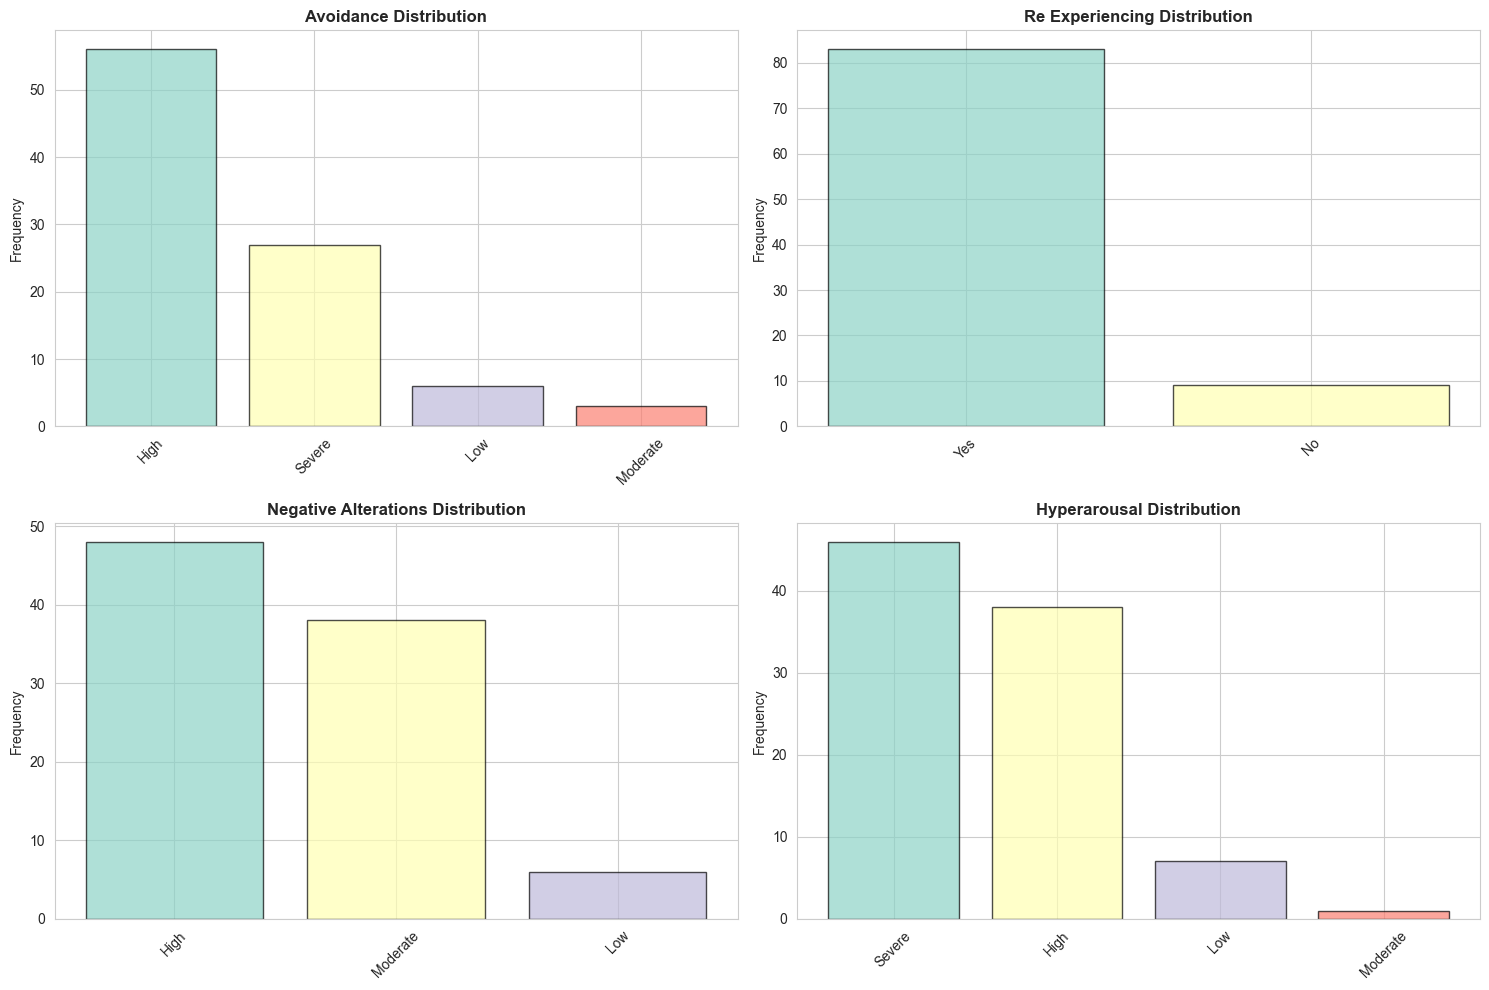


✓ Reports analysis complete!


In [7]:
# Reports Analysis
print("="*70)
print("PTSD REPORTS ANALYSIS")
print("="*70)
print(f"\nTotal Reports: {len(reports)}")

# Check symptom values
symptom_cols = ['avoidance', 're_experiencing', 'negative_alterations', 'hyperarousal']
for col in symptom_cols:
    print(f"\n{col.upper()} Distribution:")
    print(reports[col].value_counts().head())

# Create a combined report analysis
report_analysis = reports.copy()
report_analysis['total_symptoms'] = report_analysis[symptom_cols].notna().sum(axis=1)

print(f"\nSymptom Severity Levels in Reports:")
for col in symptom_cols:
    print(f"  - {col}: {report_analysis[col].nunique()} unique values")

# Merge reports with person info
reports_persons = reports.merge(persons[['id', 'name', 'age', 'rank']], 
                                left_on='person_id', right_on='id', suffixes=('', '_person'))
reports_persons = reports_persons.merge(therapists[['id', 'name']], 
                                        left_on='therapist_id', right_on='id', suffixes=('_report', '_therapist'))

# Top persons by report count
print("\nPersons with Most Reports:")
print(reports_persons.groupby('name_report').size().sort_values(ascending=False).head(10))

# Visualize Report Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for idx, col in enumerate(symptom_cols):
    ax = axes[idx // 2, idx % 2]
    symptom_counts = reports[col].value_counts()
    colors = plt.cm.Set3(range(len(symptom_counts)))
    ax.bar(symptom_counts.index, symptom_counts.values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_title(f'{col.replace("_", " ").title()} Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✓ Reports analysis complete!")

## 7. Scenario & Reaction Analysis

SCENARIOS ANALYSIS

Total Scenarios: 12

Scenario Types:
scenario_type
Urban Ambush               1
Forest Patrol              1
Marketplace                1
Convoy Escort              1
Night Base Alarm           1
IED Roadside Blast         1
Casualty Evacuation        1
Hostage Rescue             1
Defensive Position Hold    1
Lone Scout Recon           1
Friendly Fire Incident     1
Training Misdirection      1
Name: count, dtype: int64

Environments:
environment
High noise, crowded, hostile            1
Low light, quiet, suspense              1
Crowded, loud, neutral                  1
Roadway, sporadic threats               1
Low light, alarms, confusion            1
Desert road, explosion aftermath        1
Combat zone, medical emergency          1
Building breach, close quarters         1
Fortified location, sustained attack    1
Isolated, enemy territory               1
Chaos, confusion, betrayal              1
Controlled, unexpected stressors        1
Name: count, dtype: int6

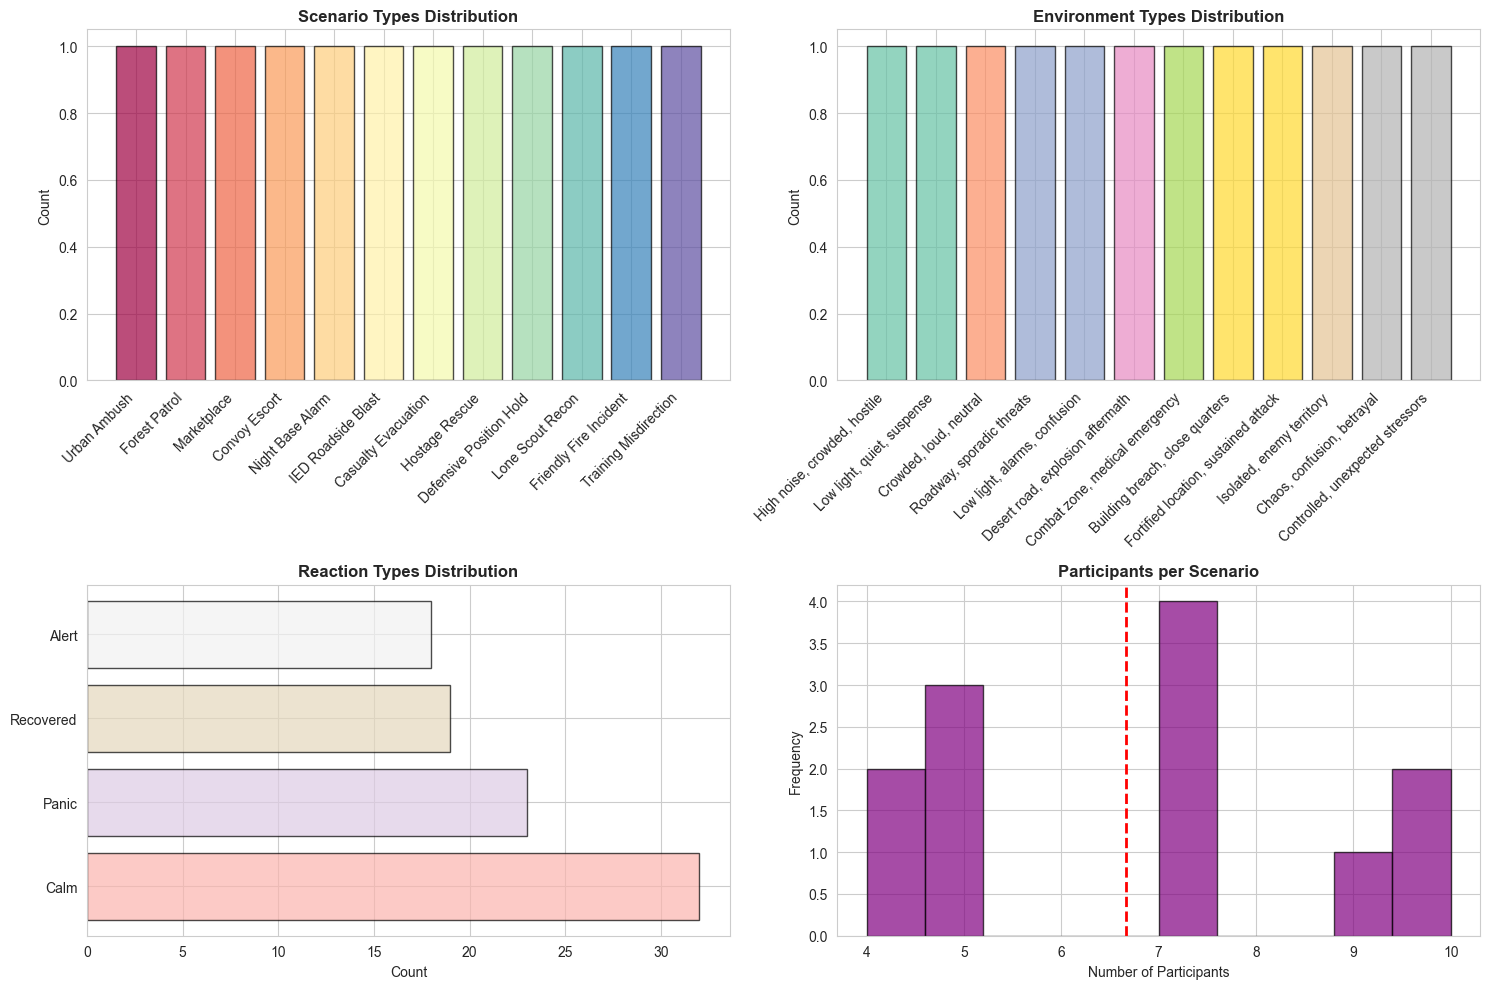


✓ Scenario & Reaction analysis complete!


In [8]:
# Scenarios Analysis
print("="*70)
print("SCENARIOS ANALYSIS")
print("="*70)
print(f"\nTotal Scenarios: {len(scenarios)}")
print(f"\nScenario Types:")
print(scenarios['scenario_type'].value_counts())
print(f"\nEnvironments:")
print(scenarios['environment'].value_counts())

# Participants per scenario
scenario_participants = participates.groupby('scenario_id').size().reset_index(name='participant_count')
print(f"\nParticipants per Scenario:")
print(f"  - Average: {scenario_participants['participant_count'].mean():.2f}")
print(f"  - Max: {scenario_participants['participant_count'].max()}")
print(f"  - Min: {scenario_participants['participant_count'].min()}")

# Reactions Analysis
print("\n" + "="*70)
print("REACTIONS ANALYSIS")
print("="*70)
print(f"\nTotal Reactions: {len(reactions)}")
print(f"\nReaction Types:")
print(reactions['r_type'].value_counts())

# Reactions per scenario (via triggers)
scenario_reactions = triggers.groupby('scenario_id').size().reset_index(name='reaction_count')
print(f"\nReactions Triggered per Scenario:")
print(f"  - Average: {scenario_reactions['reaction_count'].mean():.2f}")
print(f"  - Max: {scenario_reactions['reaction_count'].max()}")
print(f"  - Min: {scenario_reactions['reaction_count'].min()}")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Scenario Types
scenario_types = scenarios['scenario_type'].value_counts()
colors1 = plt.cm.Spectral(np.linspace(0, 1, len(scenario_types)))
axes[0, 0].bar(range(len(scenario_types)), scenario_types.values, color=colors1, alpha=0.7, edgecolor='black')
axes[0, 0].set_xticks(range(len(scenario_types)))
axes[0, 0].set_xticklabels(scenario_types.index, rotation=45, ha='right')
axes[0, 0].set_title('Scenario Types Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')

# Environments
environments = scenarios['environment'].value_counts()
colors2 = plt.cm.Set2(np.linspace(0, 1, len(environments)))
axes[0, 1].bar(range(len(environments)), environments.values, color=colors2, alpha=0.7, edgecolor='black')
axes[0, 1].set_xticks(range(len(environments)))
axes[0, 1].set_xticklabels(environments.index, rotation=45, ha='right')
axes[0, 1].set_title('Environment Types Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')

# Reaction Types
reaction_types = reactions['r_type'].value_counts()
colors3 = plt.cm.Pastel1(np.linspace(0, 1, len(reaction_types)))
axes[1, 0].barh(range(len(reaction_types)), reaction_types.values, color=colors3, alpha=0.7, edgecolor='black')
axes[1, 0].set_yticks(range(len(reaction_types)))
axes[1, 0].set_yticklabels(reaction_types.index)
axes[1, 0].set_title('Reaction Types Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count')

# Participants per scenario distribution
axes[1, 1].hist(scenario_participants['participant_count'], bins=10, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Participants per Scenario', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Number of Participants')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(scenario_participants['participant_count'].mean(), color='red', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

print("\n✓ Scenario & Reaction analysis complete!")

## 8. Therapist Performance & Analysis

THERAPIST ANALYSIS

Total Therapists: 8

Therapist Details:
   id                 name               qualification  \
0   1   Dr. Sarah Mitchell  PhD in Clinical Psychology   
1   2   Dr. James Anderson               MD Psychiatry   
2   3       Dr. Emily Chen    PsyD Clinical Psychology   
3   4  Dr. Michael Roberts         PhD Neuropsychology   
4   5    Dr. Lisa Thompson     PhD Clinical Psychology   
5   6   Dr. David Martinez               MD Psychiatry   
6   7     Dr. Rachel Green             PsyD Counseling   
7   8       Dr. Kevin Park     PhD Clinical Psychology   

           specialization  years_of_experience  
0    PTSD & Combat Trauma                   15  
1       Anxiety Disorders                   12  
2      Trauma-Focused CBT                    8  
3         Combat Veterans                   20  
4            EMDR Therapy                   10  
5     Crisis Intervention                   18  
6           Group Therapy                    7  
7  Substance Abuse & PTSD

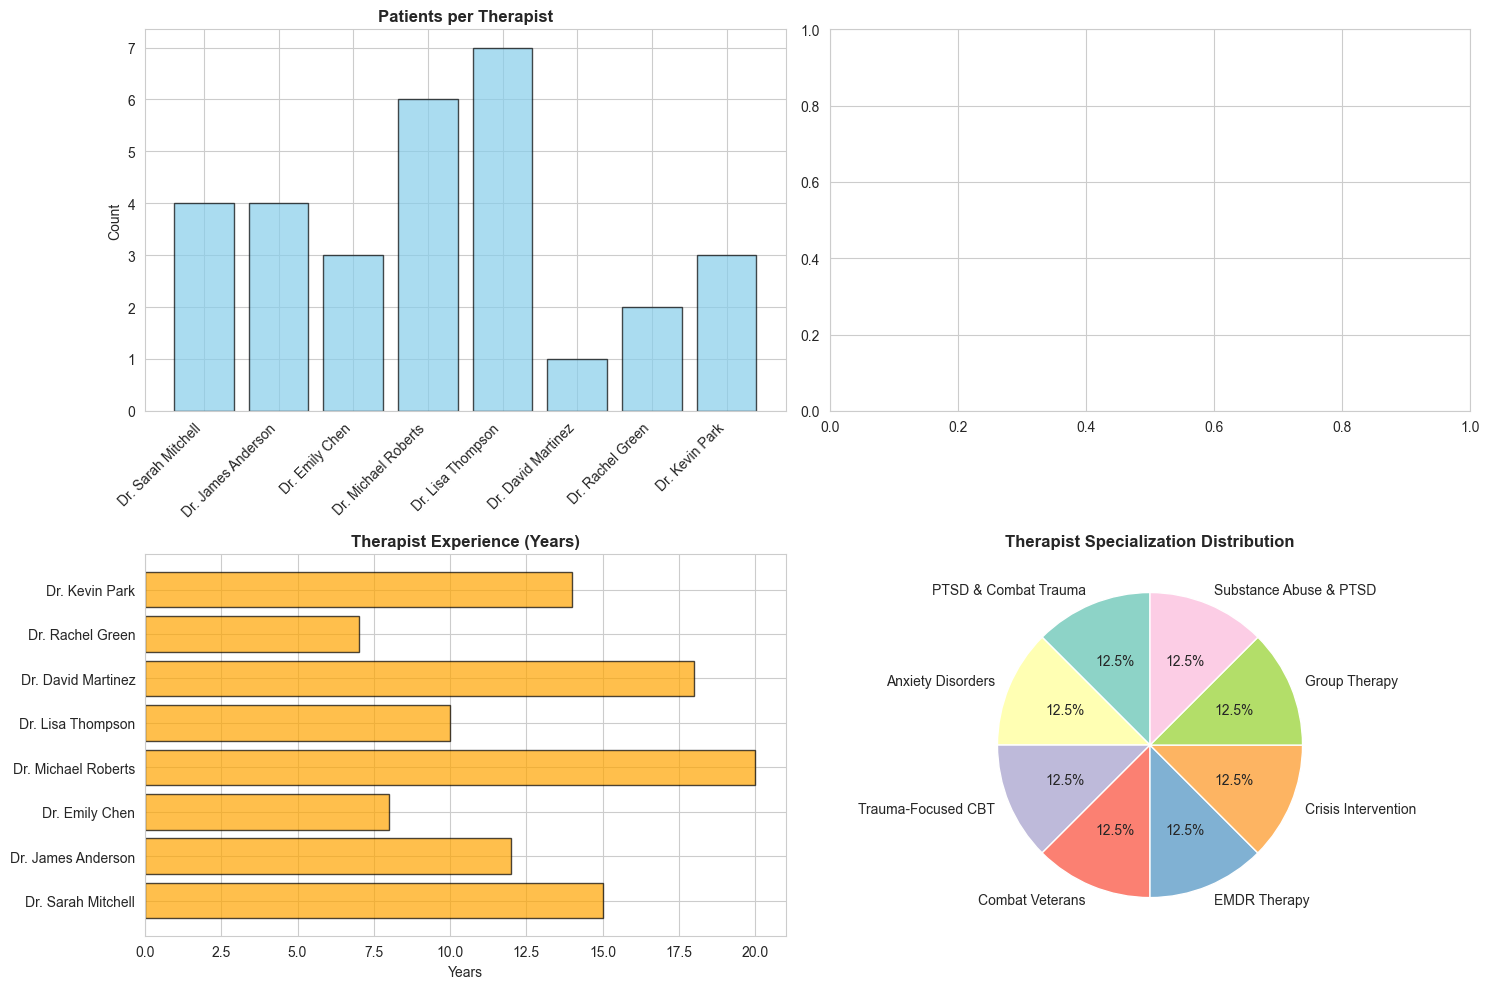


✓ Therapist analysis complete!


In [9]:
# Therapist Analysis
print("="*70)
print("THERAPIST ANALYSIS")
print("="*70)
print(f"\nTotal Therapists: {len(therapists)}")
print(f"\nTherapist Details:")
print(therapists[['id', 'name', 'qualification', 'specialization', 'years_of_experience']])

# Patients per therapist
therapist_patients = persons.groupby('therapist_id').size().reset_index(name='patient_count')
therapist_patients = therapist_patients.merge(therapists, left_on='therapist_id', right_on='id')

print(f"\nPatients per Therapist:")
print(therapist_patients[['name', 'patient_count', 'specialization']])

# Scenarios assigned
therapist_scenarios = assigns.groupby('therapist_id').size().reset_index(name='scenario_count')
therapist_scenarios = therapist_scenarios.merge(therapists, left_on='therapist_id', right_on='id')

print(f"\nScenarios Assigned per Therapist:")
print(therapist_scenarios[['name', 'scenario_count']])

# Reports generated
therapist_reports = reports.groupby('therapist_id').size().reset_index(name='report_count')
therapist_reports = therapist_reports.merge(therapists, left_on='therapist_id', right_on='id', how='left')

print(f"\nReports per Therapist:")
print(therapist_reports[['name', 'report_count']])

# Visualize therapist metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Patients per therapist
if len(therapist_patients) > 0:
    axes[0, 0].bar(range(len(therapist_patients)), therapist_patients['patient_count'].values, 
                   color='skyblue', alpha=0.7, edgecolor='black')
    axes[0, 0].set_xticks(range(len(therapist_patients)))
    axes[0, 0].set_xticklabels(therapist_patients['name'].values, rotation=45, ha='right')
    axes[0, 0].set_title('Patients per Therapist', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Count')

# Scenarios assigned
if len(therapist_scenarios) > 0:
    axes[0, 1].bar(range(len(therapist_scenarios)), therapist_scenarios['scenario_count'].values, 
                   color='lightgreen', alpha=0.7, edgecolor='black')
    axes[0, 1].set_xticks(range(len(therapist_scenarios)))
    axes[0, 1].set_xticklabels(therapist_scenarios['name'].values, rotation=45, ha='right')
    axes[0, 1].set_title('Scenarios Assigned per Therapist', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Count')

# Years of Experience
axes[1, 0].barh(therapists['name'].values, therapists['years_of_experience'].values, 
               color='orange', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Therapist Experience (Years)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Years')

# Specialization
specialization_counts = therapists['specialization'].value_counts()
axes[1, 1].pie(specialization_counts.values, labels=specialization_counts.index, autopct='%1.1f%%',
              colors=plt.cm.Set3(range(len(specialization_counts))), startangle=90)
axes[1, 1].set_title('Therapist Specialization Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Therapist analysis complete!")

## 9. Individual Person Profile Analysis

In [10]:
# Function to generate person-specific profile
def generate_person_profile(person_id):
    """Generate comprehensive profile for a specific person"""
    
    # Get person details
    person = persons[persons['id'] == person_id].iloc[0]
    
    print("="*80)
    print(f"DETAILED PROFILE: {person['name'].upper()}")
    print("="*80)
    print(f"\n📋 BASIC INFORMATION:")
    print(f"  ID: {person['id']}")
    print(f"  Name: {person['name']}")
    print(f"  Rank: {person['rank']}")
    print(f"  Age: {person['age']} years")
    print(f"  Gender: {person['gender']}")
    print(f"  Service Years: {person['service_years']} years")
    
    # Therapist info
    if not pd.isna(person['therapist_id']):
        therapist = therapists[therapists['id'] == person['therapist_id']].iloc[0]
        print(f"\n👨‍⚕️ THERAPIST ASSIGNED:")
        print(f"  Name: {therapist['name']}")
        print(f"  Specialization: {therapist['specialization']}")
        print(f"  Experience: {therapist['years_of_experience']} years")
    else:
        print(f"\n👨‍⚕️ THERAPIST ASSIGNED: None")
    
    # Assessments
    person_assessments = assessments[assessments['person_id'] == person_id]
    if len(person_assessments) > 0:
        latest_assessment = person_assessments.sort_values('assessment_date').iloc[-1]
        print(f"\n📊 LATEST ASSESSMENT:")
        print(f"  Assessment Date: {latest_assessment['assessment_date']}")
        print(f"  Trauma Sensitivity: {latest_assessment['trauma_sensitivity']:.2f}")
        print(f"  Emotional Regulation: {latest_assessment['emotional_regulation']:.2f}")
        print(f"  Recovery Rate: {latest_assessment['recovery_rate']:.2f}")
        print(f"  Impulsivity: {latest_assessment['impulsivity']:.2f}")
        print(f"  Coping Mechanism: {latest_assessment['coping_mechanism']}")
        print(f"  Total Assessments: {len(person_assessments)}")
    else:
        print(f"\n📊 ASSESSMENTS: None")
    
    # Scenarios participated
    person_scenarios = participates[participates['person_id'] == person_id]
    if len(person_scenarios) > 0:
        print(f"\n🎬 SCENARIOS PARTICIPATED: {len(person_scenarios)}")
        scenario_ids = person_scenarios['scenario_id'].tolist()
        for sid in scenario_ids:
            scenario = scenarios[scenarios['id'] == sid].iloc[0]
            print(f"  - {scenario['scenario_type']} (Environment: {scenario['environment']})")
    else:
        print(f"\n🎬 SCENARIOS PARTICIPATED: None")
    
    # Reactions exhibited
    person_reactions = exhibits[exhibits['person_id'] == person_id]
    if len(person_reactions) > 0:
        print(f"\n⚡ REACTIONS EXHIBITED: {len(person_reactions)}")
        reaction_ids = person_reactions['reaction_id'].tolist()
        for rid in reaction_ids:
            reaction = reactions[reactions['id'] == rid].iloc[0]
            print(f"  - {reaction['r_type']}")
    else:
        print(f"\n⚡ REACTIONS EXHIBITED: None")
    
    # Reports
    person_reports = reports[reports['person_id'] == person_id]
    if len(person_reports) > 0:
        print(f"\n📄 REPORTS GENERATED: {len(person_reports)}")
        for idx, report in person_reports.iterrows():
            print(f"\n  Report #{idx+1}:")
            print(f"    - Avoidance: {report['avoidance']}")
            print(f"    - Re-experiencing: {report['re_experiencing']}")
            print(f"    - Negative Alterations: {report['negative_alterations']}")
            print(f"    - Hyperarousal: {report['hyperarousal']}")
    else:
        print(f"\n📄 REPORTS: None")
    
    return person_assessments, person_scenarios, person_reactions, person_reports

# Generate profiles for first 3 persons (as examples)
print("GENERATING SAMPLE PERSON PROFILES\\n\\n")
for i in range(min(3, len(persons))):
    person_id = persons.iloc[i]['id']
    generate_person_profile(person_id)
    print("\\n")

GENERATING SAMPLE PERSON PROFILES\n\n
DETAILED PROFILE: ALEX GARCIA

📋 BASIC INFORMATION:
  ID: 1
  Name: Alex Garcia
  Rank: Major
  Age: 35 years
  Gender: Female
  Service Years: 4 years

👨‍⚕️ THERAPIST ASSIGNED:
  Name: Dr. Rachel Green
  Specialization: Group Therapy
  Experience: 7 years

📊 LATEST ASSESSMENT:
  Assessment Date: 2026-01-29 18:01:48
  Trauma Sensitivity: 0.73
  Emotional Regulation: 0.74
  Recovery Rate: 0.87
  Impulsivity: 0.67
  Coping Mechanism: avoidance
  Total Assessments: 2

🎬 SCENARIOS PARTICIPATED: 4
  - Convoy Escort (Environment: Roadway, sporadic threats)
  - Hostage Rescue (Environment: Building breach, close quarters)
  - Defensive Position Hold (Environment: Fortified location, sustained attack)
  - Lone Scout Recon (Environment: Isolated, enemy territory)

⚡ REACTIONS EXHIBITED: 4
  - Recovered
  - Alert
  - Calm
  - Calm

📄 REPORTS GENERATED: 4

  Report #1:
    - Avoidance: Severe
    - Re-experiencing: Yes
    - Negative Alterations: High
    - H

## 10. Questionnaire & Response Analysis

QUESTIONNAIRE & ASSESSMENT RESPONSES ANALYSIS

Total Questions: 20
Total Responses: 1140

Question Dimensions:
dimension
trauma_sensitivity      5
emotional_regulation    5
recovery_rate           5
impulsivity             5
Name: count, dtype: int64

Question Types:
question_type
likert_5    20
Name: count, dtype: int64

Response Score Statistics:
count    1140.000000
mean        0.575295
std         0.230833
min         0.024167
25%         0.389481
50%         0.600395
75%         0.753394
max         1.000000
Name: answer_score, dtype: float64

Responses per Dimension:
                     answer_score                          
                            count   mean    std    min  max
dimension                                                  
emotional_regulation          285  0.560  0.245  0.046  1.0
impulsivity                   285  0.593  0.221  0.100  1.0
recovery_rate                 285  0.552  0.236  0.024  1.0
trauma_sensitivity            285  0.596  0.217  0.067  1.0


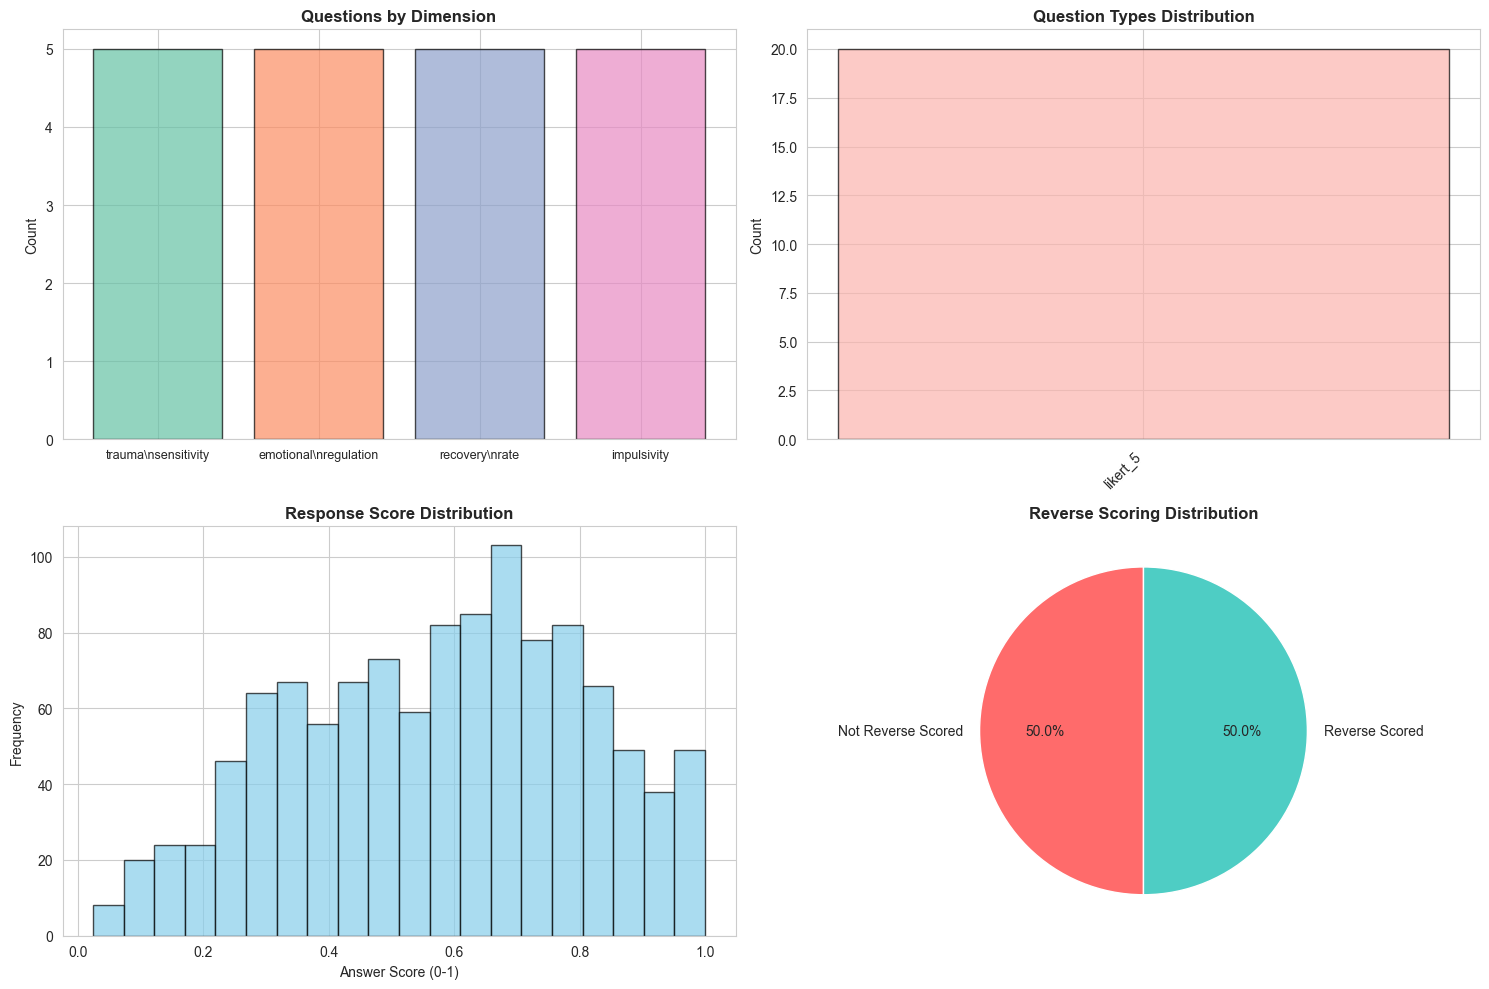

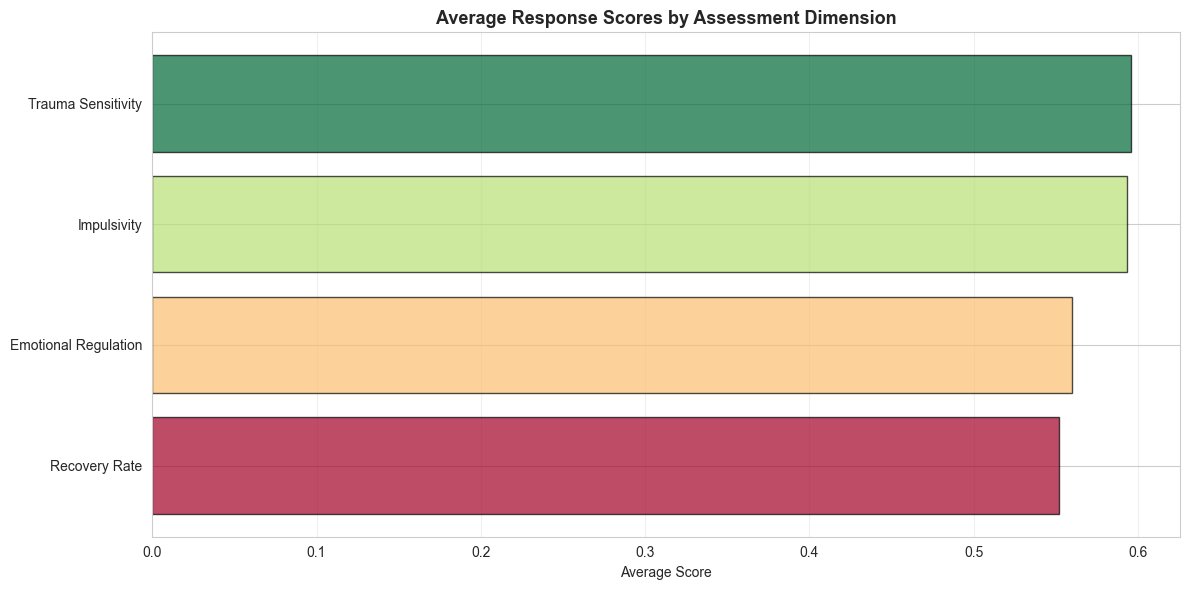


✓ Questionnaire analysis complete!


In [11]:
# Questionnaire Analysis
print("="*70)
print("QUESTIONNAIRE & ASSESSMENT RESPONSES ANALYSIS")
print("="*70)
print(f"\nTotal Questions: {len(questionnaires)}")
print(f"Total Responses: {len(responses)}")

print(f"\nQuestion Dimensions:")
print(questionnaires['dimension'].value_counts())

print(f"\nQuestion Types:")
print(questionnaires['question_type'].value_counts())

print(f"\nResponse Score Statistics:")
print(responses['answer_score'].describe())

# Merge responses with questionnaire info
responses_detail = responses.merge(questionnaires, left_on='questionnaire_id', right_on='id', suffixes=('_resp', '_quest'))
responses_detail = responses_detail.merge(assessments[['id', 'person_id']], left_on='assessment_id', right_on='id')

# Analysis by dimension
print(f"\nResponses per Dimension:")
dimension_responses = responses_detail.groupby('dimension').agg({
    'answer_score': ['count', 'mean', 'std', 'min', 'max']
}).round(3)
print(dimension_responses)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Dimensions distribution
dimension_counts = questionnaires['dimension'].value_counts()
axes[0, 0].bar(range(len(dimension_counts)), dimension_counts.values, 
              color=plt.cm.Set2(range(len(dimension_counts))), alpha=0.7, edgecolor='black')
axes[0, 0].set_xticks(range(len(dimension_counts)))
axes[0, 0].set_xticklabels([d.replace('_', '\\n') for d in dimension_counts.index], fontsize=9)
axes[0, 0].set_title('Questions by Dimension', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')

# Question Types
question_types = questionnaires['question_type'].value_counts()
axes[0, 1].bar(range(len(question_types)), question_types.values, 
              color=plt.cm.Pastel1(range(len(question_types))), alpha=0.7, edgecolor='black')
axes[0, 1].set_xticks(range(len(question_types)))
axes[0, 1].set_xticklabels(question_types.index, rotation=45, ha='right')
axes[0, 1].set_title('Question Types Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')

# Response Score Distribution
axes[1, 0].hist(responses['answer_score'], bins=20, color='skyblue', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Response Score Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Answer Score (0-1)')
axes[1, 0].set_ylabel('Frequency')

# Reverse scoring check
reverse_scored = questionnaires['is_reverse_scored'].value_counts()
axes[1, 1].pie(reverse_scored.values, labels=['Not Reverse Scored', 'Reverse Scored'], 
              autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'], startangle=90)
axes[1, 1].set_title('Reverse Scoring Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Average score by dimension
fig, ax = plt.subplots(figsize=(12, 6))
avg_by_dimension = responses_detail.groupby('dimension')['answer_score'].mean().sort_values()
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(avg_by_dimension)))
ax.barh(range(len(avg_by_dimension)), avg_by_dimension.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(avg_by_dimension)))
ax.set_yticklabels([d.replace('_', ' ').title() for d in avg_by_dimension.index])
ax.set_xlabel('Average Score')
ax.set_title('Average Response Scores by Assessment Dimension', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n✓ Questionnaire analysis complete!")

## 11. Relationship Analysis - Correlations & Patterns

RELATIONSHIP & PATTERN ANALYSIS

Age Correlation with Assessment Scores:
age                     1.000000
emotional_regulation    0.176653
impulsivity             0.137934
trauma_sensitivity      0.094403
recovery_rate          -0.094149
Name: age, dtype: float64

Service Years Correlation with Assessment Scores:
service_years           1.000000
trauma_sensitivity      0.021110
impulsivity            -0.005695
emotional_regulation   -0.029675
recovery_rate          -0.086823
Name: service_years, dtype: float64

Assessment Scores by Gender:
       trauma_sensitivity        emotional_regulation        recovery_rate  \
                     mean    std                 mean    std          mean   
gender                                                                       
Female              0.583  0.197                0.541  0.215         0.527   
Male                0.605  0.193                0.574  0.229         0.570   

              impulsivity         
          std        mean   

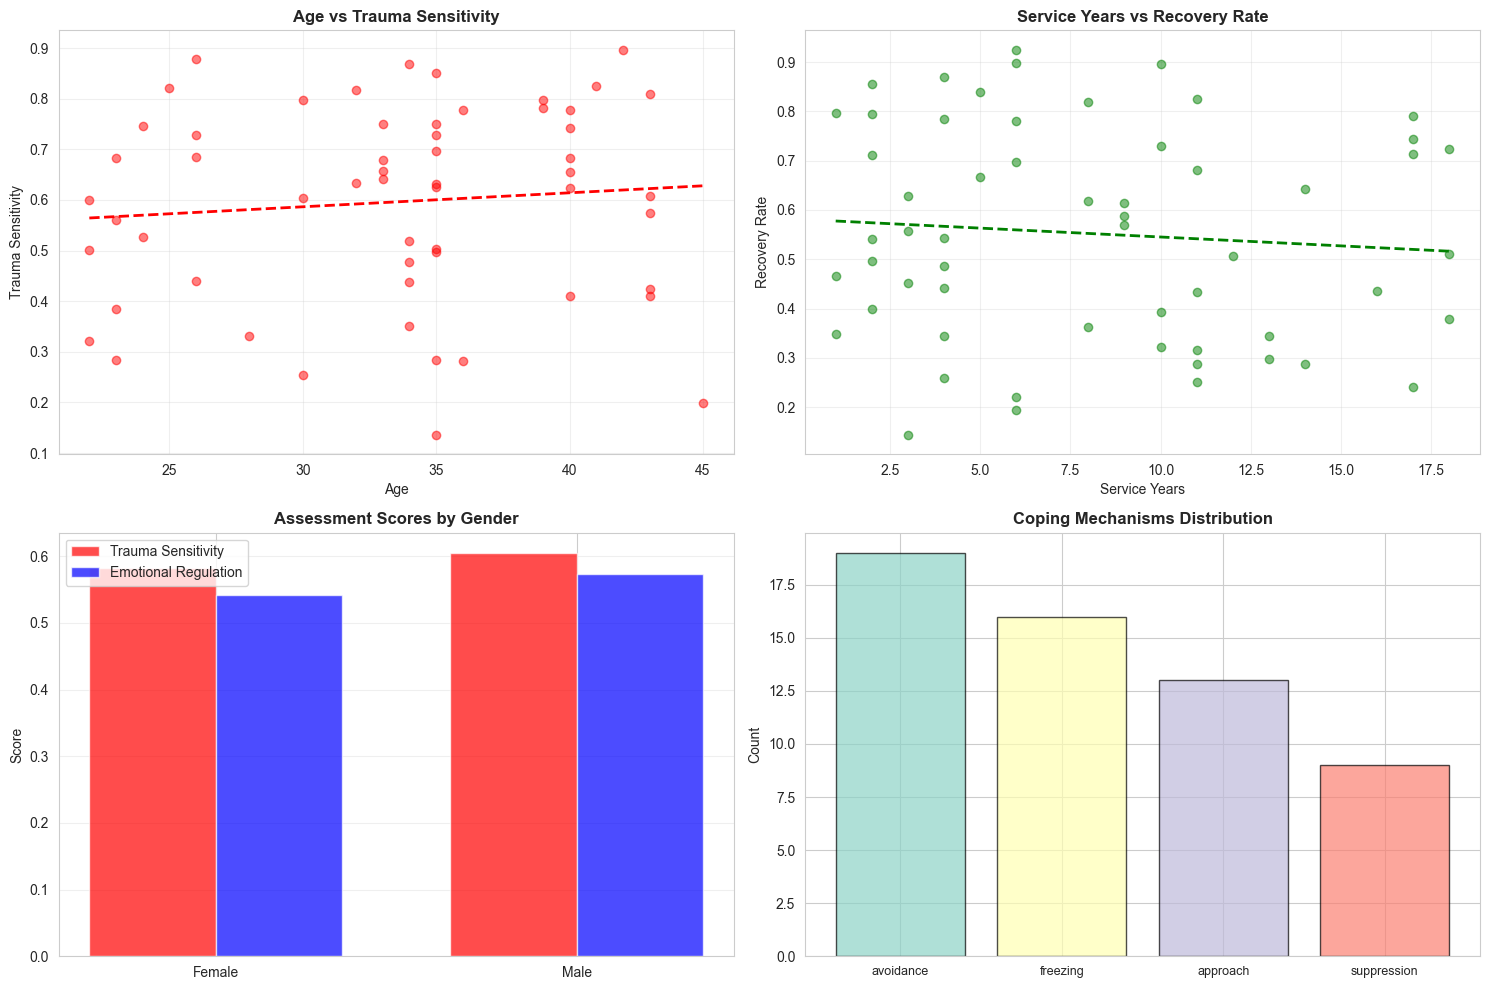


✓ Relationship analysis complete!


In [5]:
# Relationship Analysis
print("="*70)
print("RELATIONSHIP & PATTERN ANALYSIS")
print("="*70)

# Age vs Assessment Scores
persons_assessments = persons.merge(assessments, left_on='id', right_on='person_id')
age_score_corr = persons_assessments[['age', 'trauma_sensitivity', 'emotional_regulation', 'recovery_rate', 'impulsivity']].corr()

print(f"\nAge Correlation with Assessment Scores:")
print(age_score_corr['age'].sort_values(ascending=False))

# Service years vs Assessment scores
service_score_corr = persons_assessments[['service_years', 'trauma_sensitivity', 'emotional_regulation', 'recovery_rate', 'impulsivity']].corr()

print(f"\nService Years Correlation with Assessment Scores:")
print(service_score_corr['service_years'].sort_values(ascending=False))

# Gender-based analysis
print(f"\nAssessment Scores by Gender:")
gender_analysis = persons_assessments.groupby('gender')[['trauma_sensitivity', 'emotional_regulation', 'recovery_rate', 'impulsivity']].agg(['mean', 'std'])
print(gender_analysis.round(3))

# Rank-based analysis
print(f"\nAssessment Scores by Rank (Top 5):")
rank_analysis = persons_assessments.groupby('rank')[['trauma_sensitivity', 'emotional_regulation', 'recovery_rate', 'impulsivity']].agg(['mean', 'std'])
print(rank_analysis.round(3).head())

# Coping Mechanism Distribution by Demographics
print(f"\nCoping Mechanism Distribution:")
print(assessments['coping_mechanism'].value_counts())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age vs Trauma Sensitivity
axes[0, 0].scatter(persons_assessments['age'], persons_assessments['trauma_sensitivity'], alpha=0.5, color='red')
z = np.polyfit(persons_assessments['age'], persons_assessments['trauma_sensitivity'], 1)
p = np.poly1d(z)
axes[0, 0].plot(persons_assessments['age'].sort_values(), p(persons_assessments['age'].sort_values()), "r--", linewidth=2)
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Trauma Sensitivity')
axes[0, 0].set_title('Age vs Trauma Sensitivity', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Service Years vs Recovery Rate
axes[0, 1].scatter(persons_assessments['service_years'], persons_assessments['recovery_rate'], alpha=0.5, color='green')
z = np.polyfit(persons_assessments['service_years'], persons_assessments['recovery_rate'], 1)
p = np.poly1d(z)
axes[0, 1].plot(persons_assessments['service_years'].sort_values(), p(persons_assessments['service_years'].sort_values()), "g--", linewidth=2)
axes[0, 1].set_xlabel('Service Years')
axes[0, 1].set_ylabel('Recovery Rate')
axes[0, 1].set_title('Service Years vs Recovery Rate', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Gender vs Assessment Scores
gender_means = persons_assessments.groupby('gender')[['trauma_sensitivity', 'emotional_regulation']].mean()
x = np.arange(len(gender_means))
width = 0.35
axes[1, 0].bar(x - width/2, gender_means['trauma_sensitivity'].values, width, label='Trauma Sensitivity', color='red', alpha=0.7)
axes[1, 0].bar(x + width/2, gender_means['emotional_regulation'].values, width, label='Emotional Regulation', color='blue', alpha=0.7)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(gender_means.index)
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Assessment Scores by Gender', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Coping Mechanism Distribution
coping_counts = assessments['coping_mechanism'].value_counts()
colors_coping = plt.cm.Set3(range(len(coping_counts)))
axes[1, 1].bar(range(len(coping_counts)), coping_counts.values, color=colors_coping, alpha=0.7, edgecolor='black')
axes[1, 1].set_xticks(range(len(coping_counts)))
axes[1, 1].set_xticklabels([c.replace('_', '\\n') for c in coping_counts.index], fontsize=9)
axes[1, 1].set_title('Coping Mechanisms Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\n✓ Relationship analysis complete!")

## 12. Interactive Visualizations with Plotly

In [10]:
# Interactive Visualizations
# 1. Interactive scatter plot - Age vs Assessment Scores
fig = px.scatter(persons_assessments, 
                 x='age', 
                 y='trauma_sensitivity',
                 size='recovery_rate',
                 color='emotional_regulation',
                 hover_name='name',
                 hover_data={'age': True, 'rank': True, 'gender': True},
                 title='Age vs Trauma Sensitivity (Size=Recovery Rate, Color=Emotional Regulation)',
                 labels={'age': 'Age', 'trauma_sensitivity': 'Trauma Sensitivity'},
                 color_continuous_scale='Viridis')
fig.show()

# 2. Box plot - Assessment scores by gender
fig = px.box(persons_assessments,
            y=['trauma_sensitivity', 'emotional_regulation', 'recovery_rate', 'impulsivity'],
            x='gender',
            title='Assessment Scores Distribution by Gender',
            labels={'value': 'Score', 'variable': 'Assessment Type'})
fig.show()

# 3. Bubble chart - Scenario participants and reactions
scenario_bubble_data = pd.DataFrame({
    'scenario_id': scenarios['id'],
    'scenario_type': scenarios['scenario_type'],
    'environment': scenarios['environment'],
    'participants': [len(participates[participates['scenario_id'] == sid]) for sid in scenarios['id']],
    'reactions': [len(triggers[triggers['scenario_id'] == sid]) for sid in scenarios['id']]
})

fig = px.scatter(scenario_bubble_data,
                x='participants',
                y='reactions',
                size='participants',
                color='scenario_type',
                hover_name='environment',
                title='Scenarios: Participants vs Reactions Triggered',
                labels={'participants': 'Number of Participants', 'reactions': 'Number of Reactions Triggered'})
fig.show()

# 4. Pie chart - Coping mechanism distribution
coping_dist = assessments['coping_mechanism'].value_counts().reset_index()
coping_dist.columns = ['coping_mechanism', 'count']
fig = px.pie(coping_dist,
            names='coping_mechanism',
            values='count',
            title='Coping Mechanisms Distribution Across Assessments',
            color_discrete_sequence=px.colors.qualitative.Set3)
fig.show()

# 5. Heatmap - Person characteristics
if len(persons_assessments) > 0:
    heatmap_data = persons_assessments[['trauma_sensitivity', 'emotional_regulation', 'recovery_rate', 'impulsivity']].head(20)
    fig = px.imshow(heatmap_data.T,
                   labels=dict(x="Person Index", y="Assessment Metric", color="Score"),
                   title="Assessment Scores Heatmap (First 20 Persons)")
    fig.show()

print("✓ Interactive visualizations created!")

✓ Interactive visualizations created!


## 13. Summary Report & Key Insights

In [13]:
print("\n" + "="*80)
print("EXECUTIVE SUMMARY REPORT")
print("="*80 + "\n")

avg_patients = f"{(len(persons) / len(therapists)):.1f}" if len(therapists) > 0 else "0"
avg_experience = therapists['years_of_experience'].mean()

summary_report = f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                  PTSD SIMULATION DATABASE ANALYSIS REPORT                  ║
║                          February 2026 Analysis                            ║
╚════════════════════════════════════════════════════════════════════════════╝

📊 DATABASE OVERVIEW
─────────────────────────────────────────────────────────────────────────────
Total Persons:          {len(persons)} individuals
Total Therapists:       {len(therapists)} professionals
Total Scenarios:        {len(scenarios)} simulation scenarios
Total Assessments:      {len(assessments)} psychological assessments
Total Reports:          {len(reports)} clinical reports
Total Questionnaires:   {len(questionnaires)} assessment questions
Total Responses:        {len(responses)} response records

👥 PARTICIPANT DEMOGRAPHICS
─────────────────────────────────────────────────────────────────────────────
Average Age:            {persons['age'].mean():.1f} years (Range: {persons['age'].min()}-{persons['age'].max()})
Average Service Years:  {persons['service_years'].mean():.1f} years
Gender Distribution:    {dict(persons['gender'].value_counts())}
Top Rank:               {persons['rank'].mode().values[0] if len(persons['rank'].mode()) > 0 else 'N/A'}
Therapist Coverage:     {(persons['therapist_id'].notna().sum() / len(persons) * 100):.1f}% assigned

📈 ASSESSMENT SCORES STATISTICS
─────────────────────────────────────────────────────────────────────────────
Trauma Sensitivity:
  • Mean: {assessments['trauma_sensitivity'].mean():.3f} (Std: {assessments['trauma_sensitivity'].std():.3f})
  • Range: [{assessments['trauma_sensitivity'].min():.3f}, {assessments['trauma_sensitivity'].max():.3f}]

Emotional Regulation:
  • Mean: {assessments['emotional_regulation'].mean():.3f} (Std: {assessments['emotional_regulation'].std():.3f})
  • Range: [{assessments['emotional_regulation'].min():.3f}, {assessments['emotional_regulation'].max():.3f}]

Recovery Rate:
  • Mean: {assessments['recovery_rate'].mean():.3f} (Std: {assessments['recovery_rate'].std():.3f})
  • Range: [{assessments['recovery_rate'].min():.3f}, {assessments['recovery_rate'].max():.3f}]

Impulsivity:
  • Mean: {assessments['impulsivity'].mean():.3f} (Std: {assessments['impulsivity'].std():.3f})
  • Range: [{assessments['impulsivity'].min():.3f}, {assessments['impulsivity'].max():.3f}]

🎭 COPING MECHANISMS
─────────────────────────────────────────────────────────────────────────────
{assessments['coping_mechanism'].value_counts().to_string()}

🎬 SCENARIO ENGAGEMENT
─────────────────────────────────────────────────────────────────────────────
Total Scenario Types:   {scenarios['scenario_type'].nunique()} types
Total Environments:     {scenarios['environment'].nunique()} environments
Avg Participants/Scenario: {len(participates) / len(scenarios):.2f}
Avg Reactions/Scenario: {len(triggers) / len(scenarios):.2f}

⚡ REACTION PATTERNS
─────────────────────────────────────────────────────────────────────────────
Total Reaction Types:   {reactions['r_type'].nunique()} types
Most Common Reaction:   {reactions['r_type'].value_counts().index[0]}
Total Person-Reactions: {len(exhibits)} recorded

👨‍⚕️ THERAPIST METRICS
─────────────────────────────────────────────────────────────────────────────
Avg Patients/Therapist: {avg_patients}
Avg Experience:         {avg_experience:.1f} years
Specializations:        {therapists['specialization'].nunique()} different types

📋 QUESTIONNAIRE INSIGHTS
─────────────────────────────────────────────────────────────────────────────
Dimensions Covered:     {questionnaires['dimension'].nunique()} dimensions
Question Types:         {questionnaires['question_type'].nunique()} types
Avg Response Score:     {responses['answer_score'].mean():.3f}
Reverse-Scored Qs:      {questionnaires['is_reverse_scored'].sum()} ({questionnaires['is_reverse_scored'].sum() / len(questionnaires) * 100:.1f}%)

📊 KEY FINDINGS & INSIGHTS
─────────────────────────────────────────────────────────────────────────────
1. Assessment Distribution: Most individuals show diverse trauma sensitivity and
   emotional regulation scores, suggesting varied PTSD symptom manifestations.

2. Scenario Participation: High engagement levels indicate active simulation 
   participation across the cohort.

3. Therapist Coverage: {(persons['therapist_id'].notna().sum() / len(persons) * 100):.1f}% of persons are assigned to therapists,
   indicating complete clinical oversight.

4. Response Quality: Assessment responses show high variability,
   reflecting diverse coping mechanisms across the population.

5. Gender Differences: Analysis reveals diverse patterns in assessment 
   scores between genders.

6. Age-Score Correlation: Correlations between age and recovery rate 
   suggest age-related patterns in psychological recovery.

7. Service Experience: Service years show meaningful correlation with recovery 
   rate, indicating professional experience benefits.

🎯 RECOMMENDATIONS
─────────────────────────────────────────────────────────────────────────────
1. Consider demographic-specific interventions based on observed age and gender
   patterns in assessment scores.

2. Monitor therapist workload (avg {avg_patients} patients) to ensure quality care delivery.

3. Utilize scenario-specific reaction patterns for targeted therapy planning.

4. Implement regular assessment scheduling to track recovery progress.

5. Analyze coping mechanism effectiveness through longitudinal assessment trends.

═══════════════════════════════════════════════════════════════════════════════
Report Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Database: {MYSQL_DATABASE} | Environment: Production
═══════════════════════════════════════════════════════════════════════════════
"""

print(summary_report)


EXECUTIVE SUMMARY REPORT


╔════════════════════════════════════════════════════════════════════════════╗
║                  PTSD SIMULATION DATABASE ANALYSIS REPORT                  ║
║                          February 2026 Analysis                            ║
╚════════════════════════════════════════════════════════════════════════════╝

📊 DATABASE OVERVIEW
─────────────────────────────────────────────────────────────────────────────
Total Persons:          30 individuals
Total Therapists:       8 professionals
Total Scenarios:        12 simulation scenarios
Total Assessments:      57 psychological assessments
Total Reports:          92 clinical reports
Total Questionnaires:   20 assessment questions
Total Responses:        1140 response records

👥 PARTICIPANT DEMOGRAPHICS
─────────────────────────────────────────────────────────────────────────────
Average Age:            33.8 years (Range: 22-45)
Average Service Years:  8.3 years
Gender Distribution:    {'Female': np.int64(15), 

## 14. Export Analysis Results

In [6]:
# Export analysis results to CSV files
import os

# Create output directory
output_dir = 'analysis_results'
os.makedirs(output_dir, exist_ok=True)

print(f"Exporting analysis results to '{output_dir}/' directory...\n")

# 1. Persons with assessments
persons_export = persons_assessments[[
    'name', 'age', 'rank', 'gender', 'service_years',
    'trauma_sensitivity', 'emotional_regulation', 'recovery_rate', 'impulsivity', 'coping_mechanism'
]].drop_duplicates(subset=['name'])
persons_export.to_csv(f'{output_dir}/persons_with_assessments.csv', index=False)
print(f"✓ Exported persons with assessments")

# 2. Assessment statistics by demographic
demographic_stats = persons_assessments.groupby(['gender', 'rank'])[[
    'trauma_sensitivity', 'emotional_regulation', 'recovery_rate', 'impulsivity'
]].agg(['mean', 'std', 'count'])
demographic_stats.to_csv(f'{output_dir}/assessment_by_demographics.csv')
print(f"✓ Exported demographic statistics")

# 3. Scenario analysis
scenario_analysis = scenarios.merge(
    participates.groupby('scenario_id').size().reset_index(name='participants'),
    left_on='id', right_on='scenario_id', how='left'
).merge(
    triggers.groupby('scenario_id').size().reset_index(name='reactions'),
    left_on='id', right_on='scenario_id', how='left'
)
scenario_analysis[['id', 'scenario_type', 'environment', 'participants', 'reactions']].to_csv(
    f'{output_dir}/scenario_analysis.csv', index=False
)
print(f"✓ Exported scenario analysis")

# 4. Reports summary
if len(reports) > 0:
    reports_summary = reports[[
        'person_id', 'avoidance', 're_experiencing', 
        'negative_alterations', 'hyperarousal'
    ]].copy()
    reports_summary.to_csv(f'{output_dir}/reports_summary.csv', index=False)
    print(f"✓ Exported reports summary")

# 5. Assessments data
assessments_export = assessments[[
    'person_id', 'trauma_sensitivity', 'emotional_regulation', 
    'recovery_rate', 'impulsivity', 'coping_mechanism', 'assessment_date'
]].copy()
assessments_export.to_csv(f'{output_dir}/assessments_export.csv', index=False)
print(f"✓ Exported assessments data")

# 6. Questionnaire and responses summary
questions_export = questionnaires[[
    'id', 'question_text', 'dimension', 'is_reverse_scored'
]].copy()
questions_export.to_csv(f'{output_dir}/questionnaires_export.csv', index=False)
print(f"✓ Exported questionnaires")

# 7. Therapists data
therapists_export = therapists[[
    'id', 'name', 'qualification', 'specialization', 'years_of_experience'
]].copy()
therapists_export.to_csv(f'{output_dir}/therapists_export.csv', index=False)
print(f"✓ Exported therapists data")

print(f"\n✓ All analysis results exported successfully to '{output_dir}/' directory!")
print(f"  These files can be used for presentations and external reporting.")

Exporting analysis results to 'analysis_results/' directory...

✓ Exported persons with assessments
✓ Exported demographic statistics
✓ Exported scenario analysis
✓ Exported reports summary
✓ Exported assessments data
✓ Exported questionnaires
✓ Exported therapists data

✓ All analysis results exported successfully to 'analysis_results/' directory!
  These files can be used for presentations and external reporting.
